# Part 1: Data Loading and Initial Exploration 

The data for this project is stored in the `data` folder in your repositories, in the `SOTU.csv` file. The data file is structured as a CSV with columns for president name, speech text, year, and word count in the speech. 

In this section you will:

1. Import the data into a pandas dataframe
2. Perform exploratory data analysis (EDA) including specifically:
- Analyze the number of speeches per president
- Analyze the number of speeches per year
- Analyze the word count distribution
- Analyze the word count distribution accross years using a rug plot
- Analyze the average word count per president
3. Write commentary on your findings

First, create the `conda` environment with the provided yaml file. Note, it's not unusual for it to take ~15 minutes for the environment to fully install.

### Read Data

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-dark') 

In [3]:
# read in SOTU.csv using pandas, name the variable `sou` for simplicity
# the below cell is what the output should look like

In [4]:
# load in csv
sou = pd.read_csv('data/SOTU.csv')

In [5]:
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


### Exploratory Data Analysis

Replicate the plots below using the hints specified. For each plot, provide some commentary describing the results/anything interesting you might see.

#### Number of Speeches per President

In [6]:
# get the value counts of the presidents
president_counts = sou['President'].value_counts()[sou['President'].unique()]
president_counts

President
Joseph R. Biden           4
Donald J. Trump           4
Barack Obama              8
George W. Bush            8
William J. Clinton        8
George Bush               4
Ronald Reagan             8
Jimmy Carter              7
Gerald R. Ford            3
Richard M. Nixon          6
Lyndon B. Johnson         6
John F. Kennedy           3
Dwight D. Eisenhower     10
Harry S Truman            8
Franklin D. Roosevelt    11
Herbert Hoover            4
Calvin Coolidge           6
Warren G. Harding         2
Woodrow Wilson            8
William Howard Taft       4
Theodore Roosevelt        8
William McKinley          4
Grover Cleveland          8
Benjamin Harrison         4
Chester A. Arthur         4
Rutherford B. Hayes       4
Ulysses S. Grant          8
Andrew Johnson            4
Abraham Lincoln           4
James Buchanan            4
Franklin Pierce           4
Millard Fillmore          3
Zachary Taylor            1
James K. Polk             4
John Tyler                4
Martin Van

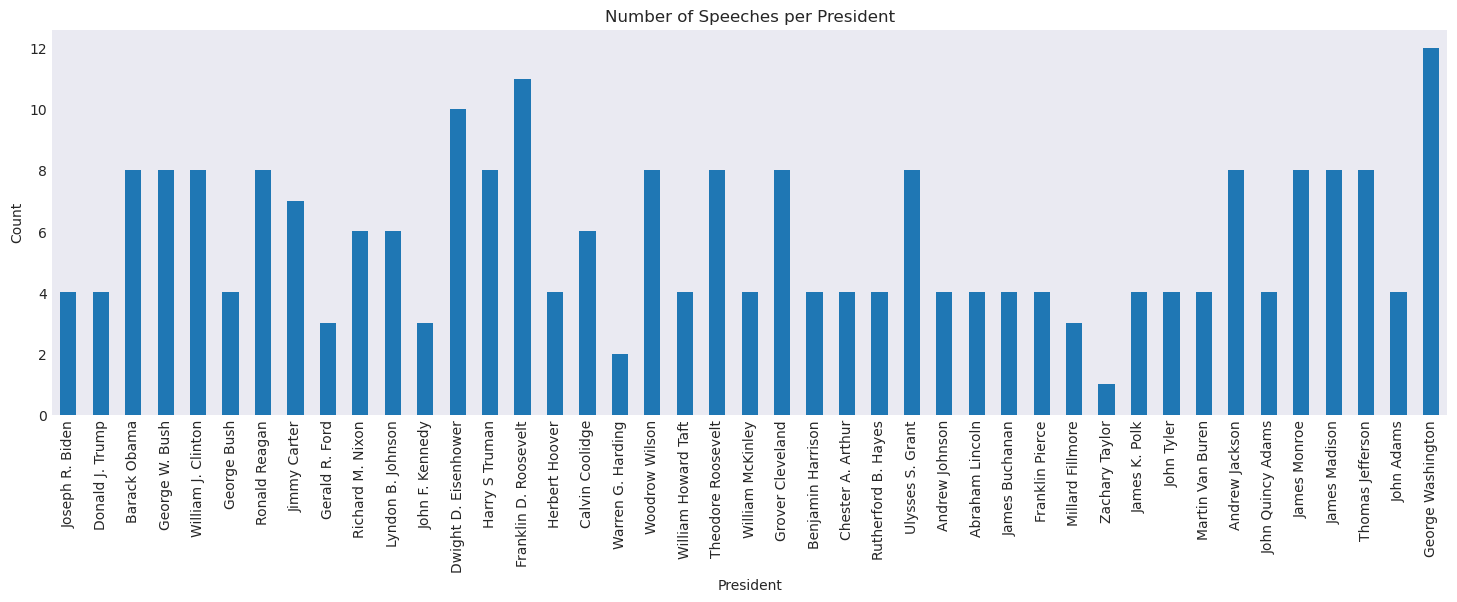

In [7]:
president_counts.plot(kind='bar', figsize=(18, 5))
plt.title('Number of Speeches per President')
plt.ylabel('Count');

In [8]:
# Plot 
# Hint - use the .plot() method for Pandas Series, make sure all presidents show up on x-axis

Observation: George Washington, the first president, had the most speeches, and Franklin Roosevelt had the second most. Zachary Taylor had the least number of speeches. There seems to be no particular trend with the number of speeches of each president chronologically.

#### Number of Speeches per Year

In [9]:
speeches_per_year = sou['Year'].value_counts().sort_index(ascending=True)
speeches_per_year

Year
1790.0    4
1791.0    2
1792.0    2
1793.0    1
1794.0    1
         ..
2020.0    1
2021.0    1
2022.0    1
2023.0    1
2024.0    1
Name: count, Length: 232, dtype: int64

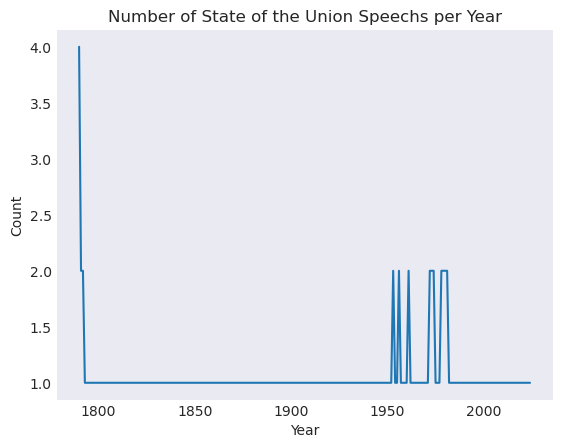

In [10]:
speeches_per_year.plot()
plt.ylabel('Count')
plt.title('Number of State of the Union Speechs per Year');

The number of speeches peaked right before 1800, and had more of a steady count from 1 to 2 per year, with 2 speeches every few years from 1950 to before 2000. After that, it dropped back to 1 speech per year.

#### Word Count Distribution 

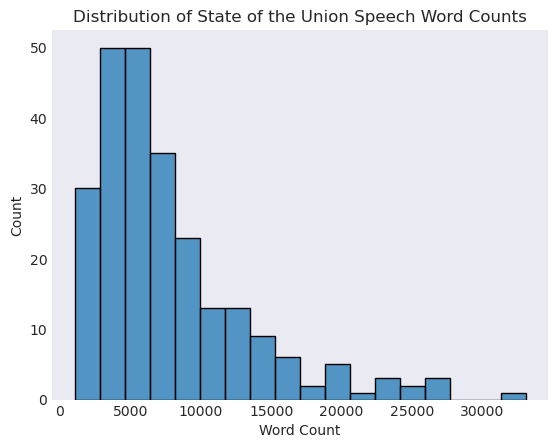

In [12]:
sns.histplot(data=sou, x='Word Count')
plt.title('Distribution of State of the Union Speech Word Counts');

Most speeches are close to 5000 words, and the distribution of the number of speeches is skewed to the right, with high numbers being around 30000 words.

#### Word Count Distribution over Year

In [14]:
min_year = sou['Year'].min()
max_year = sou['Year'].max()

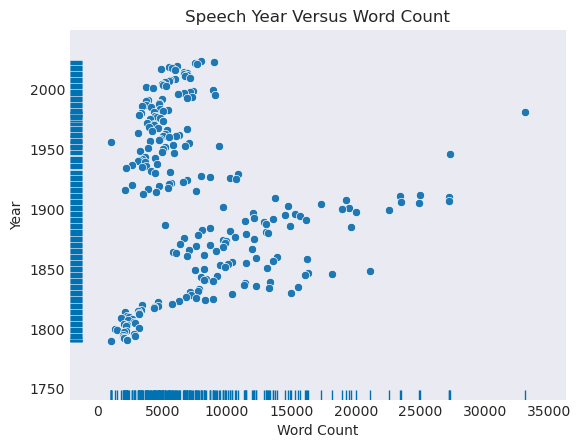

In [15]:
sns.scatterplot(data=sou, x='Word Count', y='Year')
sns.rugplot(data=sou, x='Word Count', color='#0072B2')       # bottom axis ticks
sns.rugplot(data=sou, y='Year', color='#0072B2')             # left axis ticks
plt.title('Speech Year Versus Word Count')
plt.show()

The number of words is more clustered around the lower end of the spectrum. There is somewhat of an upwards trend in number of words spoken over time, though it is unclear how strongly the word count and the year are correlated based on the visual.

#### Word Count Distribution per President

In [21]:
mean_word_count = pd.Series(sou.groupby('President').mean('Word Count')['Word Count'])[sou['President'].unique()]
mean_word_count

President
Joseph R. Biden           8063.500000
Donald J. Trump           5586.500000
Barack Obama              6624.000000
George W. Bush            4971.750000
William J. Clinton        7457.625000
George Bush               4357.500000
Ronald Reagan             4482.875000
Jimmy Carter              7874.714286
Gerald R. Ford            4495.666667
Richard M. Nixon          4427.333333
Lyndon B. Johnson         4715.833333
John F. Kennedy           5555.000000
Dwight D. Eisenhower      4703.500000
Harry S Truman            8131.625000
Franklin D. Roosevelt     3476.090909
Herbert Hoover            6251.500000
Calvin Coolidge           8529.833333
Warren G. Harding         5612.500000
Woodrow Wilson            4311.625000
William Howard Taft      22335.750000
Theodore Roosevelt       19505.125000
William McKinley         18380.000000
Grover Cleveland         13798.250000
Benjamin Harrison        13507.500000
Chester A. Arthur        10031.250000
Rutherford B. Hayes      10784.000000
Ul

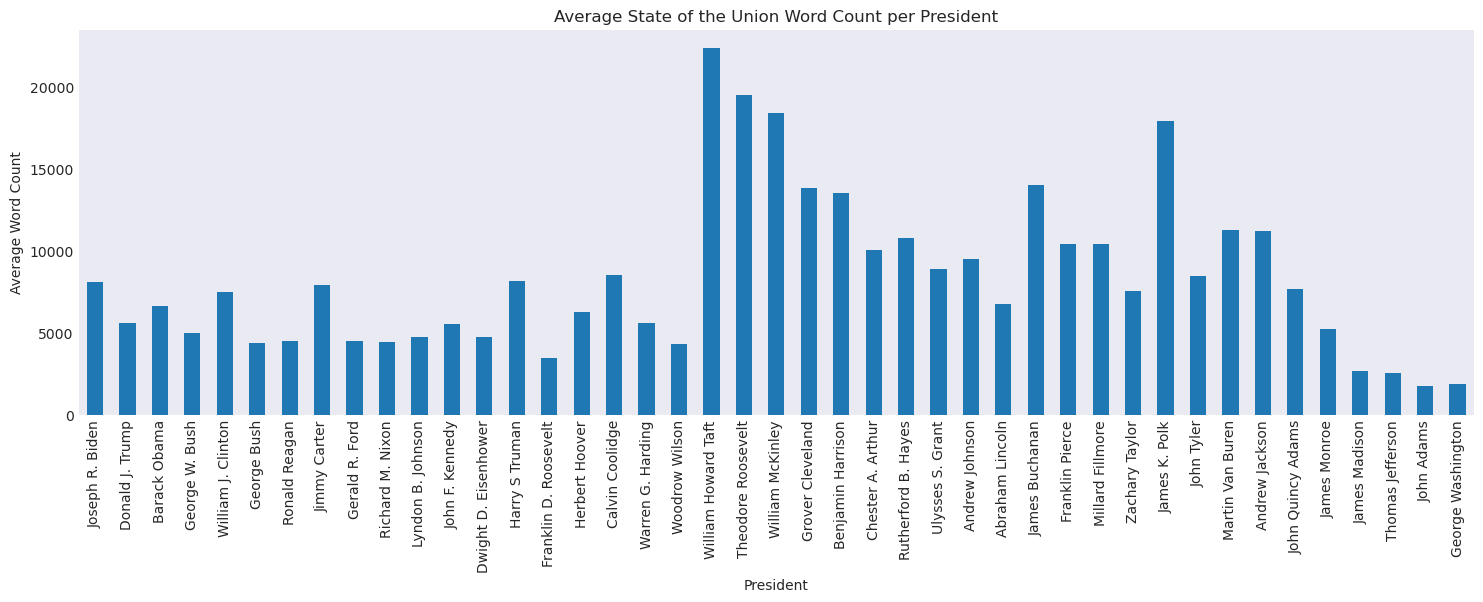

In [22]:
mean_word_count.plot(kind='bar', figsize=(18, 5))
plt.title('Average State of the Union Word Count per President')
plt.ylabel('Average Word Count');

William Howard Taft had the highest average word count, and there was an upward trend in average word count from abraham lincoln to william howard taft. After that, the word count looks pretty uniform with some fluctuations. After Taft, the maximum word count seemed to be around 7000 words.